
# Bayesian Hierarchical ARX Hurdle Model for Gravity Migration


**A. Hurdle (Bernoulli)** : 
$\text{logit}(P(\text{flow}>0)) = \alpha_d + X_h \beta_h + \beta_{lag} \text{is\_mig\_lag}$

**B. Volume (ARX)** : 
$$\log(\text{flow}) \sim \mathcal{N}(\mu_{d,t} + \phi_d (\text{lag} - \mu_{d,t-1}), \sigma_d)$$
$$\mu_{d,t} = \alpha_{V,d} + X \beta_{\text{grav}} + \beta_{\text{gdp}} \log(\text{gdpcap\_o}) + \beta_{\text{rich}} \text{is\_rich\_o}$$

**C. Variance (Geo)** : 
$\sigma_d \sim \text{HalfNormal}(\sigma_{\text{cluster}}[\text{continent\_origine}[d]])$ *(alternative à InverseGamma)*


# MÉTHODOLOGIE 
*(pour rapport ou annexe)*

1) Couplage entre bayésien & Machine Learning (Partie ARX et Variance Géo).  
Ce modèle bayésien intègre les découvertes faites par le Random Forest :
- Saut brutal de migration autour de 18 000 $ de PIB/hab. 
  Encodé par la variable indicatrice 'is_rich_o' 
- Interaction 'log_D_ij * LB_ij' (distance * frontière commune) 
  dont l'importance a été découverte par un PDP 2D du Random forest, et prouvée par régression linéaire 
- Correction des résidus : La cartographie des erreurs des XGBoost & RF montrait une incertitude 
  systématique (sous/sur-estimation) en Afrique, et un peu en Asie/Amerique latine. L'hétéroscédasticité 
  géographique modélise cette variance propre à chaque continent (à affiner par zone géo plus précise?)


2) Gestion des zéros (partie Hurdle). 
Le problème: il y a beaucoup de flux nuls, et on ne peut ni les enlever de l'analyse, ni faire log(x+1) (scientifiquement mauvais)
Forcer un pic à zéro pour loi Normale (qui ne sait faire que une cloche, et pas une cloche + un pic à zéro) fait diverger 
la variance et les chaines de Markov. 
Le modèle Hurdle: regression logistique (Bernoulli); si et seulement si le couloir est ouvert (>0) => équation de gravité ARX. 
Si non (flux=0) STAN s'arrête là et prédit 0 migrant (dans la phase de prédiction)



3) intuition physique de STAN (Hamiltonian Monte Carlo). 
Contrairement aux auteurs qui utilisaient le Gibbs sampling via JAGS, Stan utilise HMC. 
 HMC utilise la mécanique hamiltonienne pour explorer le paysage des posteriors bayésiens, (trajectoire guidée par lmes équations de Hamilton)
avec une étape d'acceptation Metropolis-Hastings à la fin selon $$P(\text{acceptation}) = \min(1, \exp(-\Delta H))$$ 
pour corriger les erreurs numériques sur la conservation de l'énergie ($$\Delta H =0$$) liées à la discrétisation de temporelle. 


Une exploration entière par Metropolis (marche aléatoire) aurait été inefficace et incroyablement lente pour autant de paramètres

4) Stabilité géométrique.  
Pour éviter que l'algorithme ne se coince (entonnoir), au lieu d'échantillonner 
directement α_d ~ N(μ, τ), on échantillonne un bruit pur ε ~ N(0,1), puis on calcule 
 α_d = μ + τ·ε. Cela détruit les corrélations pathologiques durant le HMC 

5) Approche dyadique.  
Mon modèle est purement "Dyadique" contrairement à celui de Ishagh (Inflow/Outflow). Ce code modélise chaque couloir de migration.  
On pourra comparer les deux approches in fine. 

6) Évaluation Out-Of-Sample.  
Le modèle est entraîné sur la période 1990-2010 et testé en prédiction pure sur 2015. 
Pour évaluer la qualité de la prédiction, on retient la MAE (Erreur absolue en nombre d'humains réels) et le WMAPE 
(Weighted Mean Absolute Percentage Error), qui pondére l'erreur par la taille du 
flux pour éviter l'explosion mathématique des pourcentages sur les couloirs proches de zéro.


In [2]:
# Installation des bibliothèques non classiqus
!pip install pycountry_convert arviz cmdstanpy

# compilation de Stan
import cmdstanpy
cmdstanpy.install_cmdstan()

^C
object address  : 0x104378be0
object refcount : 2
object type     : 0x103298578
object type name: KeyboardInterrupt
object repr     : KeyboardInterrupt()
lost sys.stderr
CmdStan install directory: /Users/romain/.cmdstan
CmdStan version 2.38.0 already installed
Test model compilation


True

19:17:27 - cmdstanpy - INFO - compiling stan file /var/folders/47/r5kv9z4j6kg1sk0dvr2l5ydh0000gn/T/tmp836px2u7/tmp_vqjc0kt.stan to exe file /Users/romain/Desktop/Projets DS/ProjetStat/STAN/HMC_ARX_v3
19:17:43 - cmdstanpy - INFO - compiled model executable: /Users/romain/Desktop/Projets DS/ProjetStat/STAN/HMC_ARX_v3
19:17:43 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

19:23:12 - cmdstanpy - INFO - CmdStan done processing.
19:23:12 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter[1] is 0, but must be positive! (in 'HMC_ARX_v3.stan', line 136, column 2 to column 49)
Exception: normal_lpdf: Scale parameter[16] is 0, but must be positive! (in 'HMC_ARX_v3.stan', line 136, column 2 to column 49)
Consider re-running with show_console=True if the above output is unclear!



                        Mean      MCSE    StdDev       MAD        5%  \
alpha_global       -2.371480  0.004485  0.178897  0.179986 -2.666680   
tau_alpha           0.140068  0.002820  0.110274  0.105977  0.010906   
beta_lag_global     6.653500  0.005700  0.223373  0.214269  6.290430   
mu_intercept        9.902310  0.014724  0.538630  0.540514  9.094540   
tau_mu              0.314290  0.007069  0.250915  0.237783  0.023932   
phi_global_monitor  0.946860  0.000189  0.006745  0.006807  0.935297   

                         50%        95%  ESS_bulk  ESS_tail  ESS_bulk/s  \
alpha_global       -2.370520  -2.089270   1605.25   1384.86     3.69927   
tau_alpha           0.114653   0.353691   1430.74   1283.64     3.29712   
beta_lag_global     6.648240   7.028640   1549.11   1383.91     3.56990   
mu_intercept        9.861430  10.848400   1351.92   1377.61     3.11548   
tau_mu              0.253649   0.809741   1234.21   1203.63     2.84422   
phi_global_monitor  0.947071   0.958018   12

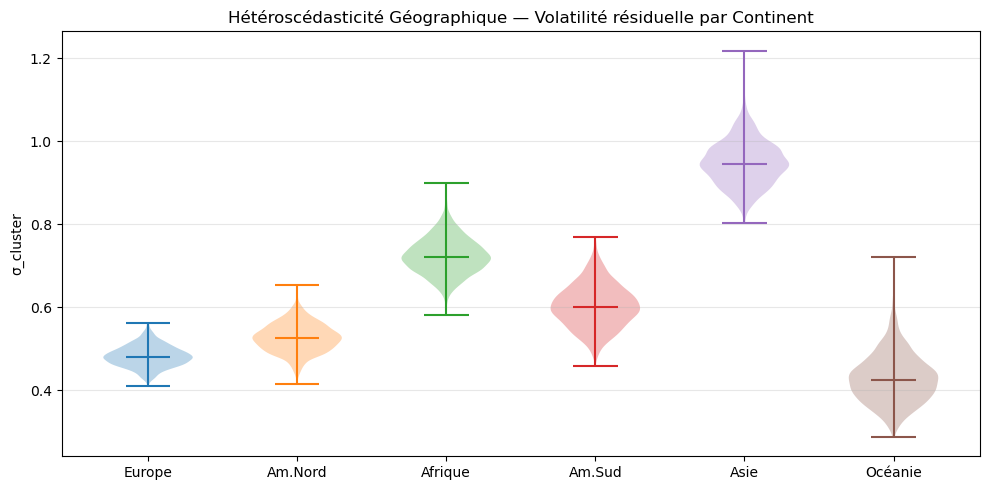

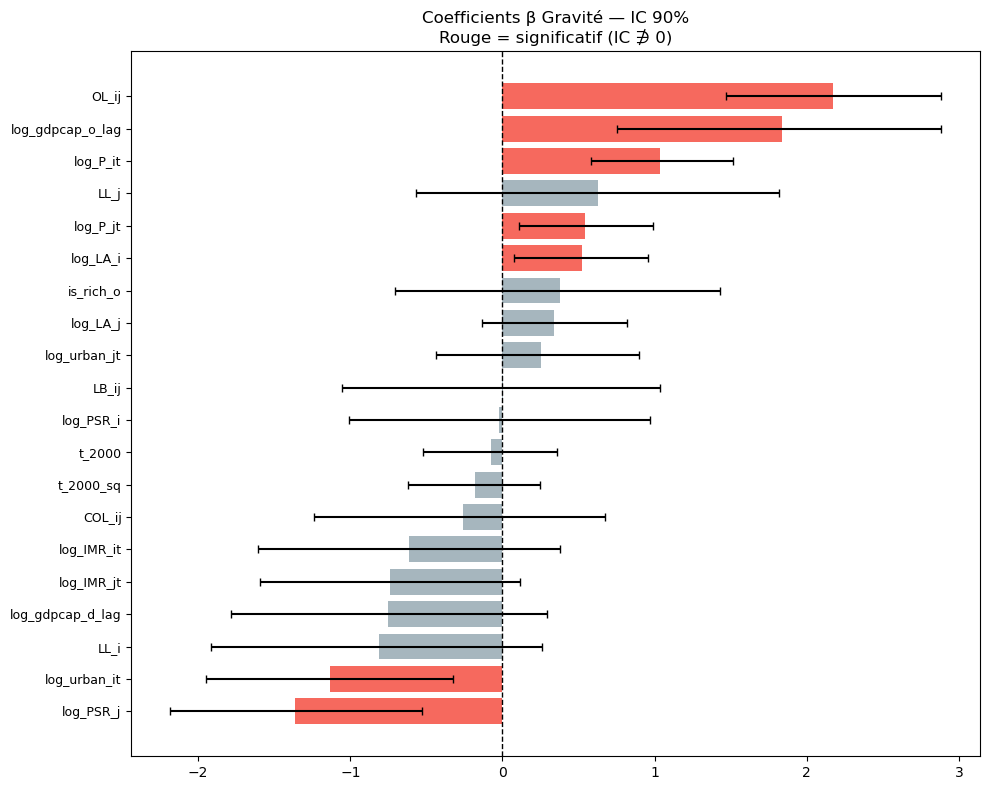

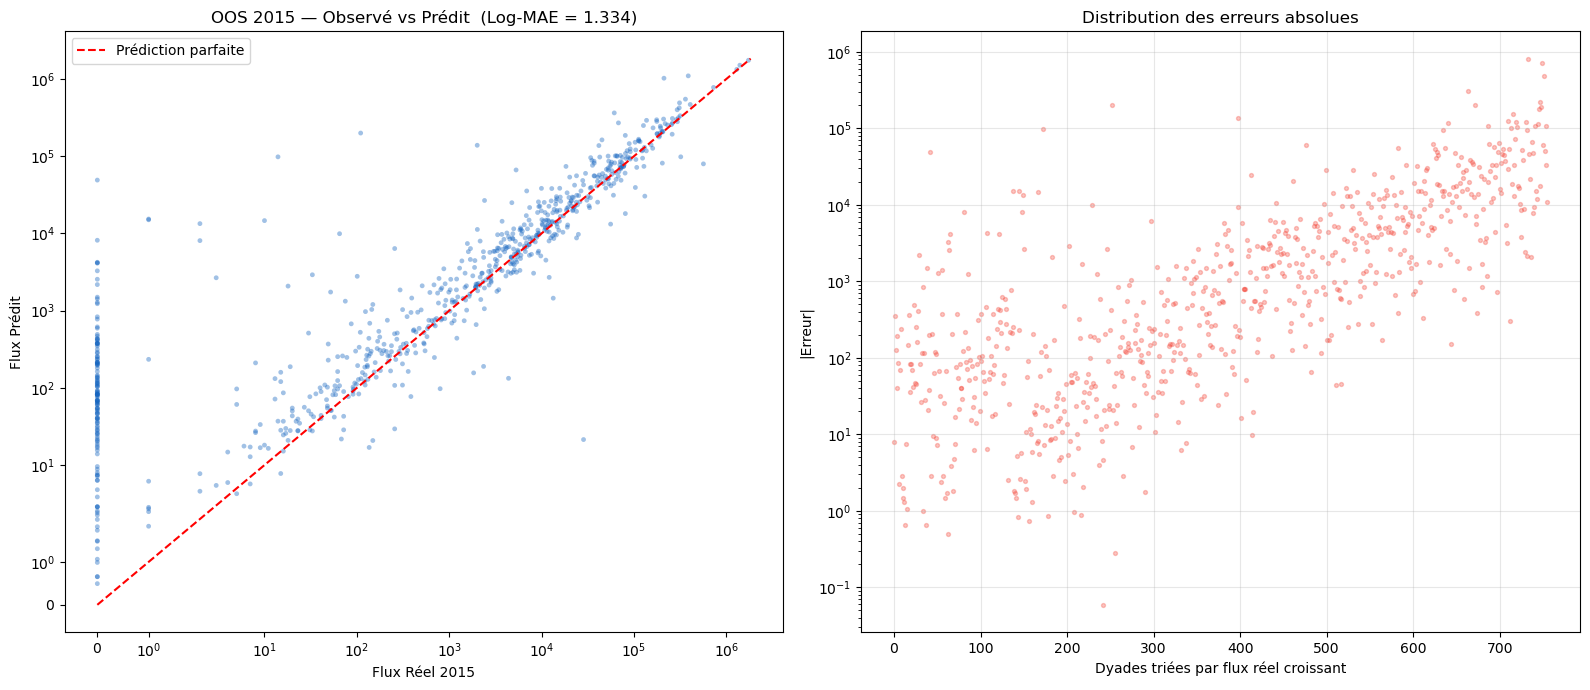

In [ ]:

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pycountry_convert as pc
from cmdstanpy import CmdStanModel
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
np.random.seed(42)




# Chargement & filtrage pays




DATA_PATH = "../data/data_final/DF_GRAVITY_sans_NaN.csv"
df_main = pd.read_csv(DATA_PATH)

#  Décommenter pour sanity-check ou simulation plus globale 

# 32 pays (développement / debug rapide)
PAYS_NORD    = ['FRA', 'USA', 'ESP', 'CAN', 'DEU', 'GBR', 'ITA', 'AUS', 'CHE']
PAYS_AFRIQUE = ['DZA', 'RWA', 'ZAF', 'NER', 'NGA', 'COD', 'SOM', 'MAR', 'EGY']
PAYS_AMLAT   = ['HTI', 'MEX', 'VEN', 'COL', 'BRA', 'SLV']
PAYS_ASIE    = ['MMR', 'IND', 'CHN', 'SYR', 'AFG', 'PAK', 'PHL', 'BGD']

"""
# 66 pays (production)
PAYS_NORD    = ['FRA', 'USA', 'ESP', 'CAN', 'DEU', 'GBR', 'ITA', 'AUS', 'CHE',
                'JPN', 'KOR', 'NLD', 'SWE', 'BEL', 'AUT', 'POL', 'NZL']
PAYS_AFRIQUE = ['DZA', 'RWA', 'ZAF', 'NER', 'NGA', 'COD', 'SOM', 'MAR', 'EGY',
               'SEN', 'CIV', 'KEN', 'ETH', 'GHA', 'AGO', 'TUN', 'CMR']
PAYS_AMLAT   = ['HTI', 'MEX', 'VEN', 'COL', 'BRA', 'SLV',
                'ARG', 'CHL', 'PER', 'ECU', 'CUB', 'DOM', 'GTM', 'BOL', 'URY']
PAYS_ASIE    = ['MMR', 'IND', 'CHN', 'SYR', 'AFG', 'PAK', 'PHL', 'BGD',
                 'VNM', 'THA', 'IDN', 'MYS', 'IRN', 'SAU', 'TUR', 'IRQ', 'ARE']
"""
PAYS_TEST = PAYS_NORD + PAYS_AFRIQUE + PAYS_AMLAT + PAYS_ASIE

df = df_main[
    df_main['orig'].isin(PAYS_TEST) &
    df_main['dest'].isin(PAYS_TEST) &
    (df_main['orig'] != df_main['dest'])
].copy()
df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)




# Clustering géographique




def get_continent_id(iso3_code):
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3_code)
        continent = pc.country_alpha2_to_continent_code(iso2)
        return {'EU': 1, 'NA': 2, 'AF': 3, 'SA': 4, 'AS': 5, 'OC': 6}.get(continent, 7)
    except Exception:
        return 7

df['continent_orig'] = df['orig'].apply(get_continent_id)
K_clusters = 6




# Features, lags et split train/test




df['is_migration'] = (df['flow'] > 0).astype(int)
df['log_flow']     = np.where(df['flow'] > 0, np.log(df['flow']), np.nan)

SEUIL_LOG_GDP       = 2.9
df['is_rich_o']     = (df['log_gdpcap_o_lag'] > SEUIL_LOG_GDP).astype(float)

df['log_D_ij']      = np.log(df['D_ij'].replace(0, np.nan))
df['logD_times_LB'] = df['log_D_ij'] * df['LB_ij']

df['dyad']          = df['orig'] + "_" + df['dest']
df['is_mig_lag']    = df.groupby('dyad')['is_migration'].shift(1)
df['log_flow_lag']  = df.groupby('dyad')['log_flow'].shift(1)
df = df.dropna(subset=['is_mig_lag']).reset_index(drop=True)

HURDLE_VARS     = ['log_D_ij', 'LB_ij', 'logD_times_LB']
ML_VARS         = ['log_gdpcap_o_lag', 'is_rich_o']
GRAVITY_VARS_RAW = ['P_it', 'P_jt', 'PSR_i', 'PSR_j', 'IMR_it', 'IMR_jt',
                    'urban_it', 'urban_jt', 'LA_i', 'LA_j']
GRAVITY_VARS_BIN = ['LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij',
                    't_2000', 't_2000_sq', 'log_gdpcap_d_lag']

for raw in GRAVITY_VARS_RAW:
    df[f'log_{raw}'] = np.log(df[raw].replace(0, np.nan))

X_VOL_COLS = [f'log_{v}' for v in GRAVITY_VARS_RAW] + GRAVITY_VARS_BIN + ML_VARS
K_grav, K_h = len(X_VOL_COLS), len(HURDLE_VARS)

df_train = df[df['year'] <= 2010].copy()
df_test  = df[df['year'] == 2015].copy()
df       = df_train  




# Séparation hurdle / volume




HURDLE_REQUIRED = HURDLE_VARS + ['is_mig_lag', 'is_migration', 'dyad', 'continent_orig']
df_hurdle = df.dropna(subset=HURDLE_REQUIRED).copy().reset_index(drop=True)

VOLUME_REQUIRED = X_VOL_COLS + ['log_flow', 'log_flow_lag', 'dyad', 'continent_orig']
df_volume = df[df['flow'] > 0].dropna(subset=VOLUME_REQUIRED).copy().reset_index(drop=True)

N_h, N_v = len(df_hurdle), len(df_volume)




# Encodage dyades et standardisation




dyades_h  = sorted(df_hurdle['dyad'].unique())
dyad_to_h = {d: i+1 for i, d in enumerate(dyades_h)}
df_hurdle['dyad_id_h'] = df_hurdle['dyad'].map(dyad_to_h)
D_h = len(dyades_h)
cluster_h = (df_hurdle.groupby('dyad')['continent_orig'].first()
             .reindex([k for k, v in sorted(dyad_to_h.items(), key=lambda x: x[1])])
             .values.astype(int))

dyades_v  = sorted(df_volume['dyad'].unique())
dyad_to_v = {d: i+1 for i, d in enumerate(dyades_v)}
df_volume['dyad_id_v'] = df_volume['dyad'].map(dyad_to_v)
D_v = len(dyades_v)
cluster_v = (df_volume.groupby('dyad')['continent_orig'].first()
             .reindex([k for k, v in sorted(dyad_to_v.items(), key=lambda x: x[1])])
             .values.astype(int))

BINARY_COLS_VOL = ['LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij', 'is_rich_o']
BINARY_COLS_HUR = ['LB_ij']

def standardize_matrix(X, col_names, binary_cols, fit_stats=None):
    X_std, stats = X.copy().astype(float), {}
    for j, col in enumerate(col_names):
        if col not in binary_cols:
            mu = X[:, j].mean() if fit_stats is None else fit_stats[col]['mean']
            sd = X[:, j].std()  if fit_stats is None else fit_stats[col]['std']
            sd = max(sd, 1e-8)
            X_std[:, j] = (X[:, j] - mu) / sd
            stats[col] = {'mean': mu, 'std': sd}
        else:
            stats[col] = {'mean': 0.0, 'std': 1.0}
    return X_std, stats

X_vol_std, stats_vol = standardize_matrix(df_volume[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL)
X_h_std,   stats_h   = standardize_matrix(df_hurdle[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR)




# Préparation du jeu de test OOS




df_test['dyad']          = df_test['orig'] + "_" + df_test['dest']
df_test['dyad_id_test']  = df_test['dyad'].map(dyad_to_h)
df_test['dyad_id_test_v']= df_test['dyad'].map(dyad_to_v).fillna(0).astype(int)

df_test = df_test.dropna(subset=['dyad_id_test']).copy().reset_index(drop=True)

df_test['continent_orig_fill'] = df_test['orig'].apply(get_continent_id)
df_test['continent_orig_fill'] = df_test['continent_orig_fill'].fillna(7).astype(int)
cluster_test_h = df_test['continent_orig_fill'].values.astype(int)

log_flow_lag_test = df_test['log_flow_lag'].fillna(0.0).values
is_mig_lag_test   = df_test['is_mig_lag'].fillna(0.0).values

X_test_v_std, _ = standardize_matrix(df_test[X_VOL_COLS].values, X_VOL_COLS,
                                     BINARY_COLS_VOL, fit_stats=stats_vol)
X_test_h_std, _ = standardize_matrix(df_test[HURDLE_VARS].values, HURDLE_VARS,
                                     BINARY_COLS_HUR, fit_stats=stats_h)




# Construction du dictionnaire Stan




stan_data = {
    'N_h'        : int(N_h),
    'D_h'        : int(D_h),
    'K_h'        : int(K_h),
    'dyad_id_h'  : df_hurdle['dyad_id_h'].astype(int).tolist(),
    'is_mig'     : df_hurdle['is_migration'].astype(int).tolist(),
    'is_mig_lag' : df_hurdle['is_mig_lag'].astype(float).tolist(),
    'X_h'        : X_h_std.tolist(),
    'cluster_h'  : cluster_h.tolist(),

    'N_v'          : int(N_v),
    'D_v'          : int(D_v),
    'K_v'          : int(K_grav),
    'dyad_id_v'    : df_volume['dyad_id_v'].astype(int).tolist(),
    'log_flow'     : df_volume['log_flow'].astype(float).tolist(),
    'log_flow_lag' : df_volume['log_flow_lag'].astype(float).tolist(),
    'X_v'          : X_vol_std.tolist(),
    'cluster_v'    : cluster_v.tolist(),

    'K_clusters'   : int(K_clusters),

    'N_test'            : int(len(df_test)),
    'dyad_id_test_h'    : df_test['dyad_id_test'].astype(int).tolist(),
    'dyad_id_test_v'    : df_test['dyad_id_test_v'].astype(int).tolist(),
    'X_h_test'          : X_test_h_std.tolist(),
    'is_mig_lag_test'   : is_mig_lag_test.tolist(),
    'X_v_test'          : X_test_v_std.tolist(),
    'log_flow_lag_test' : log_flow_lag_test.tolist(),
    'cluster_test_h'    : cluster_test_h.tolist(),
}




# Sampling Stan




STAN_FILE = "../STAN/HMC_ARX_v3.stan" 

model = CmdStanModel(stan_file=STAN_FILE)

fit = model.sample(
    data             = stan_data,
    chains           = 4,
    parallel_chains  = 4,       
    iter_warmup      = 1500,
    iter_sampling    = 1500,
    save_warmup      = False,
    seed             = 42,
    thin             = 4,       
    adapt_delta      = 0.98,
    max_treedepth    = 12,
    show_progress    = True,
)

print(fit.summary().loc[[
    'alpha_global', 'tau_alpha', 'beta_lag_global',
    'mu_intercept', 'tau_mu', 'phi_global_monitor'
]])




# Chargement ArviZ optimisé (RAM-light)




idata = az.from_cmdstanpy(
    posterior = fit,
    log_likelihood = {
        'hurdle' : 'log_lik_h',
        'volume' : 'log_lik_v',
    },
    posterior_predictive = {
        'is_mig_hat'      : 'is_mig_hat',       
        'flow_hat_jensen' : 'flow_hat_jensen',  
    },
)

print(az.summary(idata, var_names=[
    'alpha_global', 'tau_alpha', 'beta_lag_global',
    'mu_intercept', 'phi_global_monitor', 'sigma_global'
]))




# Prédictions OOS en NumPy (Jensen-corrigé, RAM-efficient)




prob_mig = fit.stan_variable('prob_mig_test')   
mu_test  = fit.stan_variable('mu_dt_test')       
sigma_t  = fit.stan_variable('sigma_test')       

flow_cond_draws = np.exp(mu_test + 0.5 * np.square(sigma_t))  

prob_med      = np.median(prob_mig,        axis=0)  
flow_cond_med = np.median(flow_cond_draws, axis=0)  
y_pred        = prob_med * flow_cond_med             

flow_all  = prob_mig * flow_cond_draws               
y_pred_q05 = np.percentile(flow_all, 5,  axis=0)
y_pred_q95 = np.percentile(flow_all, 95, axis=0)

print(f"Prédictions OOS reconstruites : {y_pred.shape[0]} observations")
print(f"  Médiane prédite : {np.median(y_pred):,.0f} migrants")
print(f"  Max prédit      : {y_pred.max():,.0f} migrants")




# Métriques OOS




y_true = df_test['flow'].values

y_true_bin = (y_true > 0).astype(int)
y_pred_bin = (y_pred > 0.5).astype(int)
acc = accuracy_score(y_true_bin, y_pred_bin)
print(f"Hurdle Accuracy (open/close) : {acc*100:.1f}%")

mask = y_true > 0
cond_mae = np.mean(np.abs(y_true[mask] - y_pred[mask]))
print(f"Conditional MAE (flow > 0)   : {cond_mae:,.0f} migrants")

global_mae  = np.mean(np.abs(y_true - y_pred))
wmape       = np.sum(np.abs(y_true - y_pred)) / (np.sum(y_true) + 1e-8) * 100
log_mae     = np.mean(np.abs(np.log1p(y_true) - np.log1p(y_pred)))
coverage    = np.mean((y_true >= y_pred_q05) & (y_true <= y_pred_q95))

print(f"\nGlobal MAE            : {global_mae:,.0f} migrants")
print(f"Global WMAPE          : {wmape:.1f}%   ← métrique principale")
print(f"Log-MAE               : {log_mae:.4f}  ← comparable aux modèles ML")
print(f"IC 90% Coverage       : {coverage*100:.1f}%  (cible ~90%)")

print(f"\n--- Benchmarks ---")
print(f"  {'Welch & Raftery (bayésien hiér.)':<35} Log-MAE ~0.35") # à verifier, et calculer MAE
print(f"  {'XGBoost (notre résultat, flow>0)':<35} MAE ~1949 migrants") # à verifier, et calculer log-MAE
print(f"  {'Random Forest (notre résultat, flow>0)':<35} MAE ~1472 migrants") # à verifier, et calculer log-MAE
print(f"  {'ARX Hurdle Bayésien (ce modèle)':<35} Log-MAE {log_mae:.3f}")




# Visualisations




CONTINENT_NAMES = {1:'Europe', 2:'Am.Nord', 3:'Afrique',
                   4:'Am.Sud', 5:'Asie', 6:'Océanie'}

fig, ax = plt.subplots(figsize=(10, 5))
sigma_draws = idata.posterior['sigma_cluster'].values  
for k in range(1, K_clusters + 1):
    draws_k = sigma_draws[..., k-1].flatten()
    ax.violinplot(draws_k, positions=[k], widths=0.6, showmedians=True)
ax.set_xticks(range(1, K_clusters + 1))
ax.set_xticklabels([CONTINENT_NAMES.get(k, f'C{k}') for k in range(1, K_clusters + 1)])
ax.set_ylabel("σ_cluster")
ax.set_title("Hétéroscédasticité Géographique — Volatilité résiduelle par Continent")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('variance_cluster.pdf', bbox_inches='tight')
plt.show()

beta_flat  = idata.posterior['beta_grav'].values.reshape(-1, K_grav)
beta_means = beta_flat.mean(axis=0)
beta_q05, beta_q95 = np.percentile(beta_flat, [5, 95], axis=0)
order = np.argsort(beta_means)

fig, ax = plt.subplots(figsize=(10, max(6, K_grav * 0.4)))
colors_coef = ['#F44336' if beta_q05[i] > 0 or beta_q95[i] < 0
               else '#90A4AE' for i in order]
ax.barh(range(K_grav), beta_means[order],
        xerr=[beta_means[order] - beta_q05[order],
              beta_q95[order]   - beta_means[order]],
        color=colors_coef, alpha=0.8, capsize=3)
ax.set_yticks(range(K_grav))
ax.set_yticklabels([X_VOL_COLS[i] for i in order], fontsize=9)
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_title("Coefficients β Gravité — IC 90%\nRouge = significatif (IC ∌ 0)")
plt.tight_layout()
plt.savefig('gravity_coefficients.pdf', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.4, s=12, color='#1565C0', edgecolors='none')
lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
ax.plot(lim, lim, 'r--', lw=1.5, label='Prédiction parfaite')
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_xlabel("Flux Réel 2015")
ax.set_ylabel("Flux Prédit")
ax.set_title(f"OOS 2015 — Observé vs Prédit  (Log-MAE = {log_mae:.3f})")
ax.legend()

ax2 = axes[1]
order_err = np.argsort(y_true)
ax2.scatter(range(len(y_true)), np.abs(y_true[order_err] - y_pred[order_err]),
            alpha=0.3, s=8, color='#F44336')
ax2.set_xlabel("Dyades triées par flux réel croissant")
ax2.set_ylabel("|Erreur|")
ax2.set_yscale('log')
ax2.set_title("Distribution des erreurs absolues")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_scatter.pdf', bbox_inches='tight')
plt.show()

In [5]:
summary = fit.summary()

# Hyperparamètres globaux uniquement (lisible)
params_watch = [
    'alpha_global', 'tau_alpha', 'beta_lag_global',
    'mu_intercept', 'tau_mu', 'phi_global_monitor',
    'sigma_global', 'tau_sigma', 'tau_phi',
    'sigma_cluster[1]', 'sigma_cluster[2]', 'sigma_cluster[3]',
    'sigma_cluster[4]', 'sigma_cluster[5]', 'sigma_cluster[6]',
]

# Filtre sur les params qui existent vraiment dans le summary
params_found = [p for p in params_watch if p in summary.index]
print(summary.loc[params_found, ['Mean', 'StdDev', '5%', '95%', 'R_hat', 'ESS_bulk']])

print(f"\nR_hat max (tous paramètres) : {summary['R_hat'].max():.4f}")
print(f"ESS_bulk min               : {summary['ESS_bulk'].min():.0f}")
print(f"Nb divergences             : {fit.divergences.sum()}")


                        Mean    StdDev        5%        95%     R_hat  \
alpha_global       -2.367940  0.171731 -2.650520  -2.098080  0.999314   
tau_alpha           0.137975  0.108387  0.012584   0.351681  1.003300   
beta_lag_global     6.668680  0.223378  6.301880   7.025760  1.005840   
mu_intercept        9.921200  0.508190  9.141850  10.801800  0.999505   
tau_mu              0.319291  0.251338  0.021752   0.790329  0.999220   
phi_global_monitor  0.947567  0.006533  0.936610   0.957715  1.001120   
sigma_global        0.571735  0.209703  0.238053   0.925330  0.999664   
tau_sigma           0.578670  0.025710  0.536085   0.620007  0.999169   
tau_phi             0.062286  0.043384  0.005040   0.142898  0.999919   
sigma_cluster[1]    0.482505  0.026199  0.441493   0.527390  0.999477   
sigma_cluster[2]    0.527201  0.036345  0.468458   0.586851  0.998846   
sigma_cluster[3]    0.727151  0.044590  0.655046   0.803984  0.999480   
sigma_cluster[4]    0.600338  0.051255  0.520818   

In [6]:
beta_draws = fit.stan_variable('beta_grav')  # (n_draws, K_grav)
beta_means = beta_draws.mean(axis=0)
beta_q05   = np.percentile(beta_draws, 5,  axis=0)
beta_q95   = np.percentile(beta_draws, 95, axis=0)

print(f"{'Variable':<25} {'Moyenne':>10} {'IC 5%':>10} {'IC 95%':>10}  {'Significatif?':>14}")
print("-" * 65)
for j, col in enumerate(X_VOL_COLS):
    sig = "✓ OUI" if (beta_q05[j] > 0 or beta_q95[j] < 0) else "  non"
    print(f"{col:<25} {beta_means[j]:>10.3f} {beta_q05[j]:>10.3f} {beta_q95[j]:>10.3f}  {sig:>14}")

Variable                     Moyenne      IC 5%     IC 95%   Significatif?
-----------------------------------------------------------------
log_P_it                       1.034      0.561      1.502           ✓ OUI
log_P_jt                       0.538      0.086      1.009           ✓ OUI
log_PSR_i                     -0.002     -0.992      0.944             non
log_PSR_j                     -1.376     -2.164     -0.603           ✓ OUI
log_IMR_it                    -0.631     -1.688      0.346             non
log_IMR_jt                    -0.730     -1.572      0.155             non
log_urban_it                  -1.138     -1.896     -0.324           ✓ OUI
log_urban_jt                   0.264     -0.441      0.938             non
log_LA_i                       0.523      0.098      0.958           ✓ OUI
log_LA_j                       0.341     -0.110      0.801             non
LL_i                          -0.844     -2.010      0.320             non
LL_j                           0.5

Figure 1: le Graal, ce serait des formes étalées horizontalement, basses sur l'axe des Y (modèle sûr de lui + volatilité basse). 
Figure 2: 

à faire: optimiser ArviZ 